# Pandas Practice: Bike Share Trip Data

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme, cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../assets/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [20]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bike_share_201402_trip_data.csv")
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1: Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [21]:
# Number of trips (rows)
len(df)

144015

### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [22]:
# Lowercase, spaces -> "_", "#" -> "num"
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("#", "num")
)
print(df.columns.tolist())

['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal', 'end_date', 'end_station', 'end_terminal', 'bike_num', 'subscription_type', 'zip_code']


---

## Part 2: Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [23]:
# Number of subscription types and their names
print(df["subscription_type"].nunique())
df["subscription_type"].unique()

2


<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [24]:
# Trips per subscription type
sub_counts = df["subscription_type"].value_counts()
sub_counts

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

### Challenge 5: Visualise subscription frequency, pie chart

Plot the frequency of each subscription type as a pie chart.

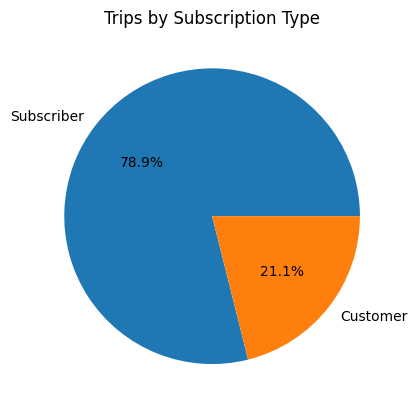

In [25]:
# Pie chart of subscription types
sub_counts.plot(kind="pie", autopct="%1.1f%%", title="Trips by Subscription Type")
plt.ylabel("")
plt.show()

### Challenge 6: Visualise subscription frequency, bar chart

Plot the same data as a bar chart.

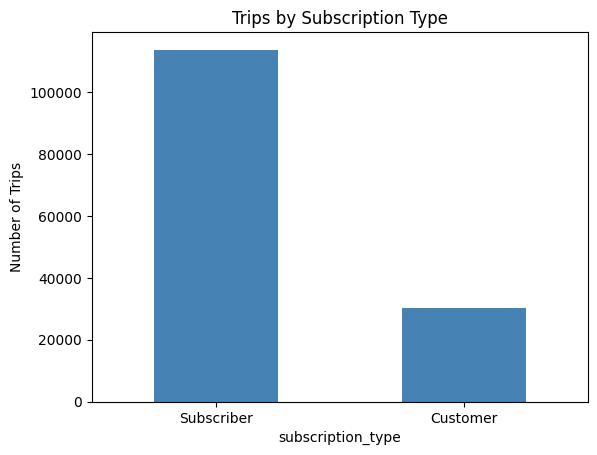

In [26]:
# Bar chart of subscription types
sub_counts.plot(kind="bar", title="Trips by Subscription Type", color="steelblue", rot=0)
plt.ylabel("Number of Trips")
plt.show()

---

## Part 3: Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [27]:
# 10 most frequent start stations
df["start_station"].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [28]:
# 10 least frequent end stations
df["end_station"].value_counts().tail(10)

end_station
Broadway St at Battery St           205
Redwood City Medical Center         178
Castro Street and El Camino Real    129
Redwood City Public Library         117
San Mateo County Center             106
Franklin at Maple                    93
San Antonio Shopping Center          93
Broadway at Main                     56
San Jose Government Center           23
Mezes Park                            5
Name: count, dtype: int64

### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [29]:
# Trips per start station and subscription type, with totals ("All")
pd.crosstab(df["start_station"], df["subscription_type"], margins=True)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


---

## Part 4: Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [30]:
# Duration is in seconds: the first trip starts 14:13 and ends 14:14 with duration 63
print(df["duration"].describe())

print("Shortest:", df["duration"].min(), "s")
print("Longest: ", df["duration"].max(), "s =", round(df["duration"].max() / 3600 / 24, 1), "days")
print("Trips as short as the minimum:", (df["duration"] == df["duration"].min()).sum())

count    144015.000000
mean       1230.910141
std        6652.962329
min          60.000000
25%         349.000000
50%         531.000000
75%         797.000000
max      722236.000000
Name: duration, dtype: float64
Shortest: 60 s
Longest:  722236 s = 8.4 days
Trips as short as the minimum: 17


### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

In [31]:
# "Long" trip: more than 30 minutes. Bike share passes include 30 minutes per trip,
# longer trips cost extra, so 30 min is a natural threshold.
long_threshold = 30 * 60  # seconds
long_trips = df[df["duration"] > long_threshold]
print("Long trips:", len(long_trips), f"({len(long_trips) / len(df):.1%} of all trips)")

# Who makes the long trips?
long_trips["subscription_type"].value_counts()

Long trips: 9287 (6.4% of all trips)


subscription_type
Customer      8501
Subscriber     786
Name: count, dtype: int64

### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

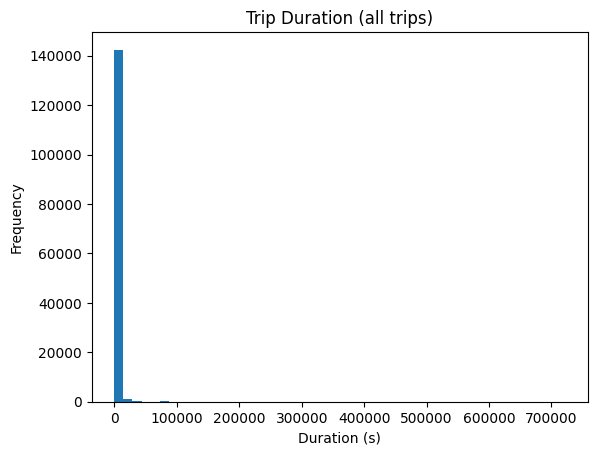

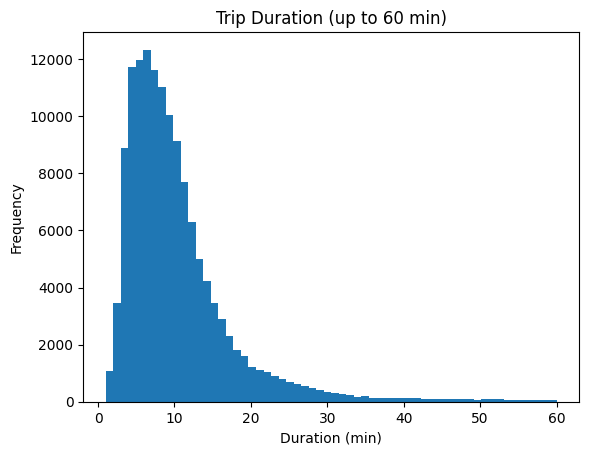

In [32]:
# Full range: a few extreme values squeeze everything into one bar
df["duration"].plot(kind="hist", bins=50, title="Trip Duration (all trips)")
plt.xlabel("Duration (s)")
plt.show()

# Trips up to 1 hour, in minutes
(df.loc[df["duration"] <= 3600, "duration"] / 60).plot(
    kind="hist", bins=60, title="Trip Duration (up to 60 min)"
)
plt.xlabel("Duration (min)")
plt.show()

---

## Part 5: Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead, it will be much faster.

In [33]:
# Lowercase, every run of non-alphanumeric characters -> "_", no leading/trailing "_"
station_cols = ["start_station", "end_station"]
df[station_cols] = df[station_cols].apply(
    lambda s: s.str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

df[station_cols].head()

,start_station,end_station
0,south_van_ness_at_market,south_van_ness_at_market
1,san_jose_city_hall,san_jose_city_hall
2,mountain_view_city_hall,mountain_view_city_hall
3,san_jose_city_hall,san_jose_city_hall
4,south_van_ness_at_market,market_at_10th


### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data: it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

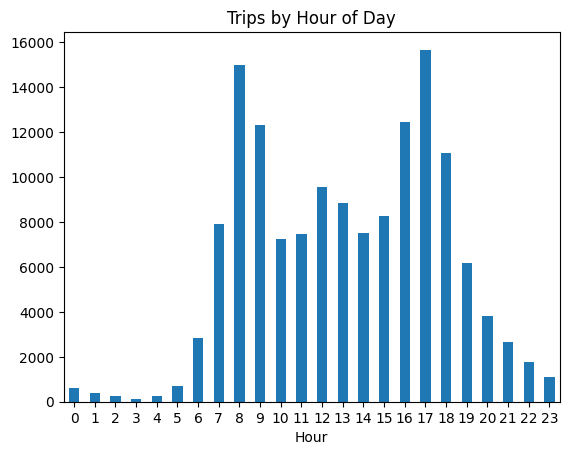

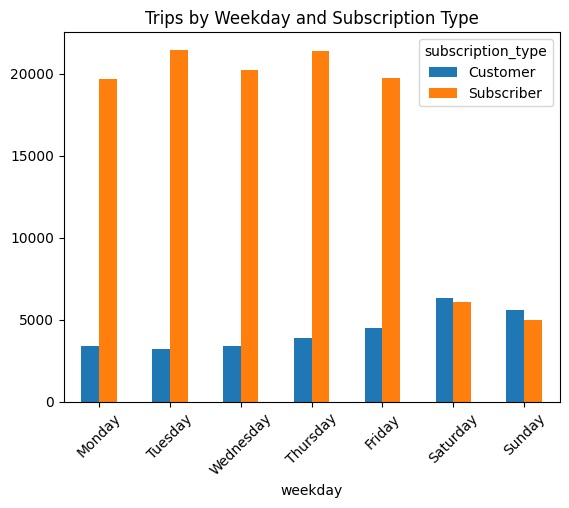

subscription_type
Customer      17.80
Subscriber     7.85
Name: duration, dtype: float64

In [34]:
# When are bikes used? Parse the start date first
df["start_date"] = pd.to_datetime(df["start_date"], format="%m/%d/%Y %H:%M")
df["hour"] = df["start_date"].dt.hour
df["weekday"] = df["start_date"].dt.day_name()

# Trips per hour of day: commuter peaks in the morning and evening?
df["hour"].value_counts().sort_index().plot(kind="bar", title="Trips by Hour of Day", rot=0)
plt.xlabel("Hour")
plt.show()

# Subscribers vs customers by weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pd.crosstab(df["weekday"], df["subscription_type"]).loc[weekday_order].plot(
    kind="bar", title="Trips by Weekday and Subscription Type", rot=45
)
plt.show()

# Median trip duration in minutes per subscription type
df.groupby("subscription_type")["duration"].median() / 60

---

## Bonus: Trip Distance from Station Coordinates

The trip data has no coordinates, but the original Bay Area Bike Share open data includes a station file with latitude and longitude for every station (`../data/bike_share_201402_station_data.csv`, from `babs_open_data_year_1.zip`).

We join the coordinates via the terminal IDs (more robust than station names) and compute the **straight-line distance** with the haversine formula. The real route along streets is longer.

In [35]:
# Station coordinates, joined via terminal ID
stations = pd.read_csv("../data/bike_share_201402_station_data.csv")
coords = stations.set_index("station_id")[["lat", "long"]]

df["start_lat"] = df["start_terminal"].map(coords["lat"])
df["start_long"] = df["start_terminal"].map(coords["long"])
df["end_lat"] = df["end_terminal"].map(coords["lat"])
df["end_long"] = df["end_terminal"].map(coords["long"])

# Every terminal found?
df[["start_lat", "end_lat"]].isna().sum()

start_lat    0
end_lat      0
dtype: int64

In [36]:
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km, works on whole columns at once."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(df["start_lat"], df["start_long"], df["end_lat"], df["end_long"])

# Average speed in km/h, only for trips that end at a different station
df["speed_kmh"] = (df["distance_km"] / (df["duration"] / 3600)).where(df["distance_km"] > 0)

df[["start_station", "end_station", "duration", "distance_km", "speed_kmh"]].head()

,start_station,end_station,duration,distance_km,speed_kmh
0,south_van_ness_at_market,south_van_ness_at_market,63,0.000000,NaN
1,san_jose_city_hall,san_jose_city_hall,70,0.000000,NaN
2,mountain_view_city_hall,mountain_view_city_hall,71,0.000000,NaN
3,san_jose_city_hall,san_jose_city_hall,77,0.000000,NaN
4,south_van_ness_at_market,market_at_10th,83,0.243515,10.562094


Round trips (same start and end station): 6878


count    144015.000000
mean          1.290676
std           0.872372
min           0.000000
25%           0.779519
50%           1.192307
75%           1.692168
max          68.066696
Name: distance_km, dtype: float64

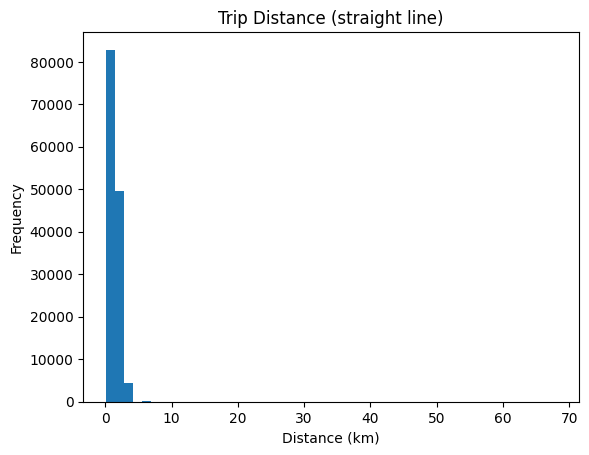

,distance_km,speed_kmh
subscription_type,,
Customer,1.207836,5.820013
Subscriber,1.192307,9.733103


In [37]:
# Distance overview
print("Round trips (same start and end station):", (df["distance_km"] == 0).sum())
display(df["distance_km"].describe())

# Distribution of distances, round trips excluded
df.loc[df["distance_km"] > 0, "distance_km"].plot(kind="hist", bins=50, title="Trip Distance (straight line)")
plt.xlabel("Distance (km)")
plt.show()

# Median distance and speed per subscription type
df.groupby("subscription_type")[["distance_km", "speed_kmh"]].median()

In [38]:
# Longest station-to-station connections that were actually ridden
(
    df.groupby(["start_station", "end_station"])["distance_km"]
    .agg(["first", "size"])
    .rename(columns={"first": "distance_km", "size": "trips"})
    .sort_values("distance_km", ascending=False)
    .head(10)
)

,,distance_km,trips
start_station,end_station,,
san_jose_civic_center,civic_center_bart_7th_at_market,68.066696,1
paseo_de_san_antonio,market_at_4th,67.946256,1
market_at_4th,paseo_de_san_antonio,67.946256,1
san_francisco_city_hall,san_jose_city_hall,67.825248,1
san_francisco_caltrain_townsend_at_4th,san_jose_diridon_caltrain_station,66.042625,1
san_antonio_shopping_center,civic_center_bart_7th_at_market,50.047830,1
california_ave_caltrain_station,market_at_sansome,46.084365,1
powell_street_bart,university_and_emerson,43.483812,1
san_francisco_caltrain_2_330_townsend,university_and_emerson,42.223376,2


### Stations on a Map

Interactive map with [folium](https://python-visualization.github.io/folium/) (OpenStreetMap tiles). Circle size = number of trips starting at the station, blue lines = the 30 most frequent routes between different stations. Click a circle for details, zoom with the mouse wheel.

In [39]:
import folium

# Trips starting and ending per station, joined to the station table
station_stats = stations.set_index("station_id").assign(
    starts=df["start_terminal"].value_counts(),
    ends=df["end_terminal"].value_counts(),
).fillna({"starts": 0, "ends": 0})

# Map centred on all stations
m = folium.Map(tiles="OpenStreetMap")
m.fit_bounds([
    [station_stats["lat"].min(), station_stats["long"].min()],
    [station_stats["lat"].max(), station_stats["long"].max()],
])

# 30 most frequent routes (round trips excluded)
top_routes = (
    df[df["start_terminal"] != df["end_terminal"]]
    .groupby(["start_terminal", "end_terminal"])
    .size()
    .nlargest(30)
)
for (start, end), trips in top_routes.items():
    folium.PolyLine(
        [coords.loc[start].tolist(), coords.loc[end].tolist()],
        weight=1 + trips / top_routes.max() * 6,
        color="steelblue",
        opacity=0.6,
        tooltip=f"{trips} trips",
    ).add_to(m)

# One circle per station, size by number of starts
for station_id, row in station_stats.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["long"]],
        radius=3 + (row["starts"] / station_stats["starts"].max()) ** 0.5 * 15,
        color="darkred",
        fill=True,
        fill_opacity=0.6,
        tooltip=row["name"],
        popup=f"<b>{row['name']}</b><br>{row['landmark']}<br>"
              f"Starts: {int(row['starts'])}<br>Ends: {int(row['ends'])}<br>Docks: {row['dockcount']}",
    ).add_to(m)

m